# Clasificación de Enfermedades Cardíacas con Modelos Bayesianos

**Autores:** Andrés Parejo, Santiago Hurtado, Juan Marín

- **Dataset:** Heart Disease UCI (Cleveland Clinic Foundation, 303 pacientes)
- **Modelo principal:** `GaussianNB` dentro de un `Pipeline` de scikit-learn

---

## 1. Objetivo y contexto aplicado

### 1.1 Objetivo general

Aplicar un modelo supervisado de clasificación basado en la probabilidad bayesiana (`GaussianNB`) para predecir la presencia o ausencia de enfermedad cardíaca en pacientes a partir de indicadores clínicos. Específicamente, se busca:

1. Construir un **pipeline** de preprocesamiento y clasificación usando `GaussianNB`.
2. Evaluar el desempeño del modelo usando métricas estándar y visualizaciones.
3. Analizar el impacto de cada variable en la predicción desde la perspectiva probabilística.

### 1.2 Contexto aplicado

Los sistemas de salud buscan modelos interpretables que apoyen el diagnóstico temprano de enfermedades. Uno de los problemas más frecuentes es el diagnóstico de enfermedad cardíaca, donde se dispone de múltiples mediciones clínicas y se requiere estimar el riesgo de forma transparente.

Los clasificadores bayesianos son una herramienta especialmente adecuada para este contexto por tres razones:

- **Rapidez**: se entrenan y predicen en tiempo prácticamente instantáneo, incluso en equipos con recursos limitados.
- **Simplicidad**: no requieren búsqueda de hiperparámetros complejos.
- **Interpretabilidad probabilística**: entregan una probabilidad explícita de enfermedad, no solo una etiqueta, lo cual es directamente comunicable al personal médico como un "riesgo estimado".

## 2. Descripción del dataset

**Fuente:** [UCI Machine Learning Repository — Heart Disease Data Set](https://archive.ics.uci.edu/ml/datasets/Heart+Disease) (subconjunto *Cleveland*, 303 pacientes, recolectado por la Cleveland Clinic Foundation).

| Variable | Tipo | Descripción |
|---|---|---|
| `age` | Numérica | Edad del paciente (años) |
| `sex` | Categórica (binaria) | Sexo (1 = hombre, 0 = mujer) |
| `cp` | Categórica | Tipo de dolor torácico (1 = angina típica, 2 = angina atípica, 3 = no anginoso, 4 = asintomático) |
| `trestbps` | Numérica | Presión arterial en reposo (mm Hg) |
| `chol` | Numérica | Colesterol sérico (mg/dl) |
| `fbs` | Categórica (binaria) | Azúcar en sangre en ayunas > 120 mg/dl (1 = sí, 0 = no) |
| `restecg` | Categórica | Resultado electrocardiográfico en reposo (0, 1, 2) |
| `thalach` | Numérica | Frecuencia cardíaca máxima alcanzada |
| `exang` | Categórica (binaria) | Angina inducida por ejercicio (1 = sí, 0 = no) |
| `oldpeak` | Numérica | Depresión del segmento ST inducida por ejercicio relativo al reposo |
| `slope` | Categórica | Pendiente del segmento ST en el pico del ejercicio |
| `ca` | Categórica | Número de vasos principales coloreados por fluoroscopia (0-3) |
| `thal` | Categórica | Resultado de la prueba de talio (3 = normal, 6 = defecto fijo, 7 = defecto reversible) |
| `num` | Objetivo (original) | Diagnóstico angiográfico (0 = sin enfermedad, 1-4 = presencia y severidad) |

El archivo `data/heart_disease.csv` ya tiene encabezados asignados y los valores faltantes originales (marcados con `?` en el archivo crudo de UCI) fueron convertidos a `NaN`; la limpieza propiamente dicha se realiza explícitamente más abajo, dentro de este notebook.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.naive_bayes import GaussianNB, BernoulliNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, roc_auc_score,
    ConfusionMatrixDisplay,
)
from sklearn.inspection import permutation_importance

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

sns.set_theme(style="whitegrid")
PALETTE = ["#4C72B0", "#DD8452"]  # [Sin enfermedad, Con enfermedad]
plt.rcParams["figure.dpi"] = 100
%matplotlib inline

## 3. Carga de datos

In [2]:
df = pd.read_csv("../data/heart_disease.csv")
print("Dimensiones:", df.shape)
df.head()

Dimensiones: (303, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    float64
 7   thalach   303 non-null    float64
 8   exang     303 non-null    float64
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    float64
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
 13  num       303 non-null    int64  
dtypes: float64(13), int64(1)
memory usage: 33.3 KB


### 3.1 Valores faltantes

El dataset original de UCI codifica los valores faltantes con `?`; al preparar el CSV ya se convirtieron a `NaN`. Los inspeccionamos explícitamente antes de decidir cómo tratarlos.

In [4]:
missing = df.isna().sum()
missing[missing > 0]

ca      4
thal    2
dtype: int64

Hay **4 valores faltantes en `ca`** y **2 en `thal`**, ambas variables categóricas. Se imputarán más adelante usando la **moda**, mediante un `SimpleImputer` dentro del propio `Pipeline` — de esa forma la imputación se aprende solo con el conjunto de entrenamiento y no se filtra información del conjunto de prueba (*data leakage*).

## 4. Variable objetivo

La columna original `num` codifica el diagnóstico angiográfico en 5 niveles (0 = sin enfermedad, 1 a 4 = presencia y severidad creciente). Siguiendo el enunciado del proyecto, se binariza a `target` (1 = enfermedad presente, 0 = ausencia).

In [5]:
df["target"] = (df["num"] > 0).astype(int)
df = df.drop(columns=["num"])
df["target"].value_counts()

target
0    164
1    139
Name: count, dtype: int64

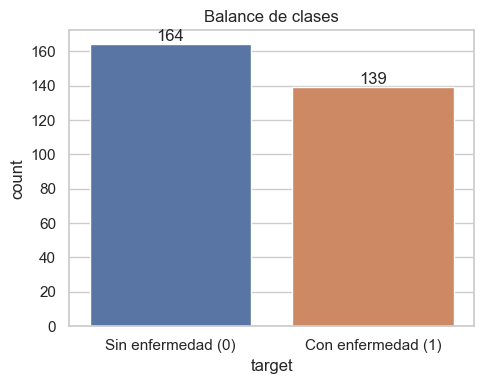

In [6]:
plt.figure(figsize=(5, 4))
ax = sns.countplot(data=df, x="target", hue="target", palette=PALETTE, legend=False)
ax.set_xticks([0, 1])
ax.set_xticklabels(["Sin enfermedad (0)", "Con enfermedad (1)"])
ax.set_title("Balance de clases")
for p in ax.patches:
    ax.annotate(f"{int(p.get_height())}", (p.get_x() + p.get_width() / 2, p.get_height()),
                ha="center", va="bottom")
plt.tight_layout()
plt.show()

La distribución es **164 pacientes sin enfermedad (54.1%)** y **139 con enfermedad (45.9%)**: un balance razonable que no requiere técnicas de remuestreo (*oversampling/undersampling*).

## 5. Análisis Exploratorio de Datos (EDA)

### 5.1 Variables numéricas

In [7]:
numeric_features = ["age", "trestbps", "chol", "thalach", "oldpeak"]
categorical_features = ["sex", "cp", "fbs", "restecg", "exang", "slope", "ca", "thal"]

df[numeric_features].describe().T

,count,mean,std,min,25%,50%,75%,max
age,303.0,54.438944,9.038662,29.0,48.0,56.0,61.0,77.0
trestbps,303.0,131.689769,17.599748,94.0,120.0,130.0,140.0,200.0
chol,303.0,246.693069,51.776918,126.0,211.0,241.0,275.0,564.0
thalach,303.0,149.607261,22.875003,71.0,133.5,153.0,166.0,202.0
oldpeak,303.0,1.039604,1.161075,0.0,0.0,0.8,1.6,6.2


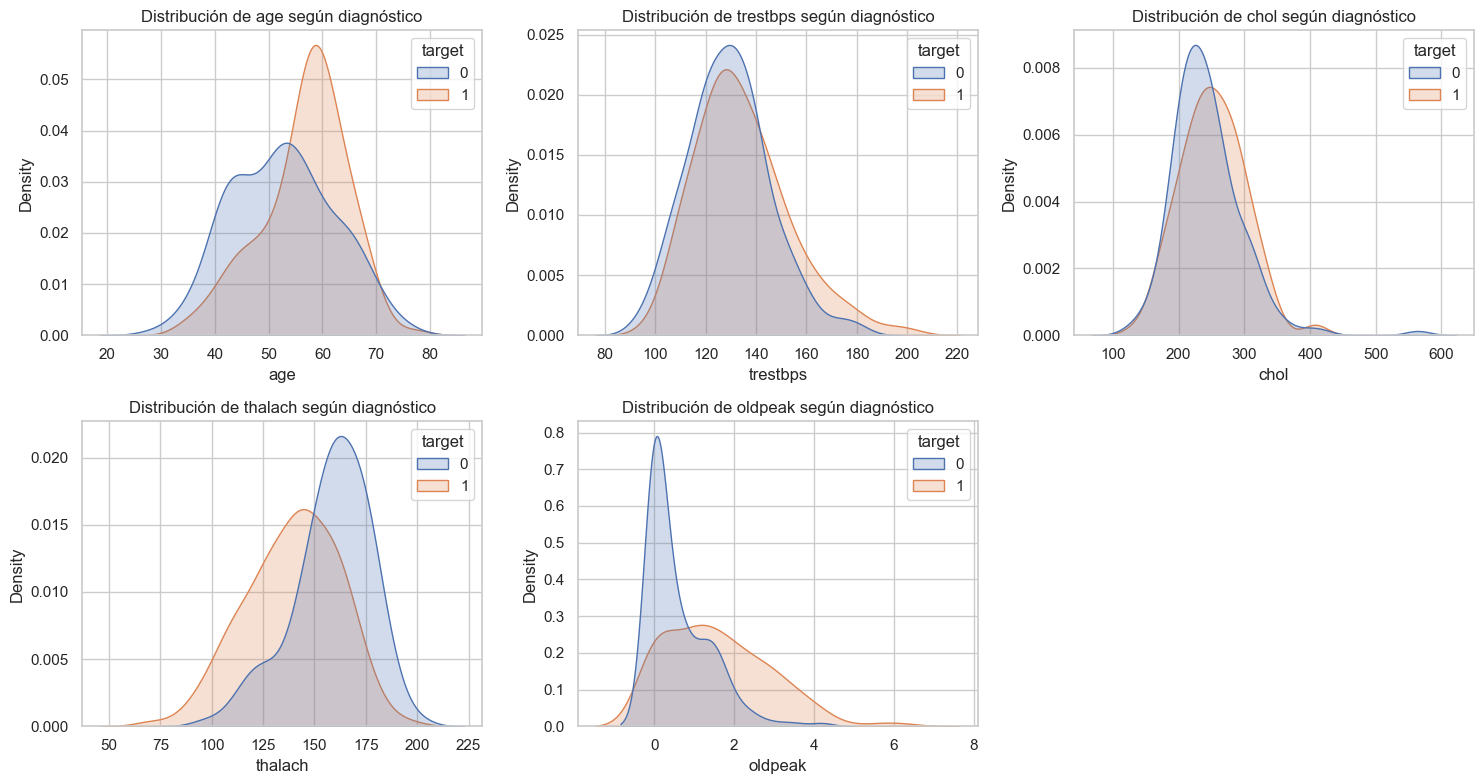

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
for i, col in enumerate(numeric_features):
    sns.kdeplot(data=df, x=col, hue="target", fill=True, common_norm=False,
                ax=axes[i], palette=PALETTE)
    axes[i].set_title(f"Distribución de {col} según diagnóstico")
axes[-1].axis("off")
plt.tight_layout()
plt.show()

In [9]:
df.groupby("target")[numeric_features].mean().round(2)

,age,trestbps,chol,thalach,oldpeak
target,,,,,
0,52.59,129.25,242.64,158.38,0.59
1,56.63,134.57,251.47,139.26,1.57


**Lectura de resultados (valores reales calculados arriba):**

- **`thalach`** (frecuencia cardíaca máxima): 158.4 en pacientes sanos vs. **139.3** en pacientes enfermos → menor capacidad de alcanzar frecuencias cardíacas altas, consistente con una reserva cardíaca reducida.
- **`oldpeak`** (depresión del ST): 0.59 vs. **1.57** → mayor depresión del segmento ST inducida por ejercicio en el grupo enfermo, marcador clásico de isquemia miocárdica.
- **`age`**: 52.6 vs. 56.6 años → los pacientes con enfermedad son, en promedio, algo mayores.
- **`trestbps`** y **`chol`**: diferencias más leves (129→135 mmHg y 243→251 mg/dl) → menor poder discriminante individual que `thalach` u `oldpeak`.

### 5.2 Variables categóricas

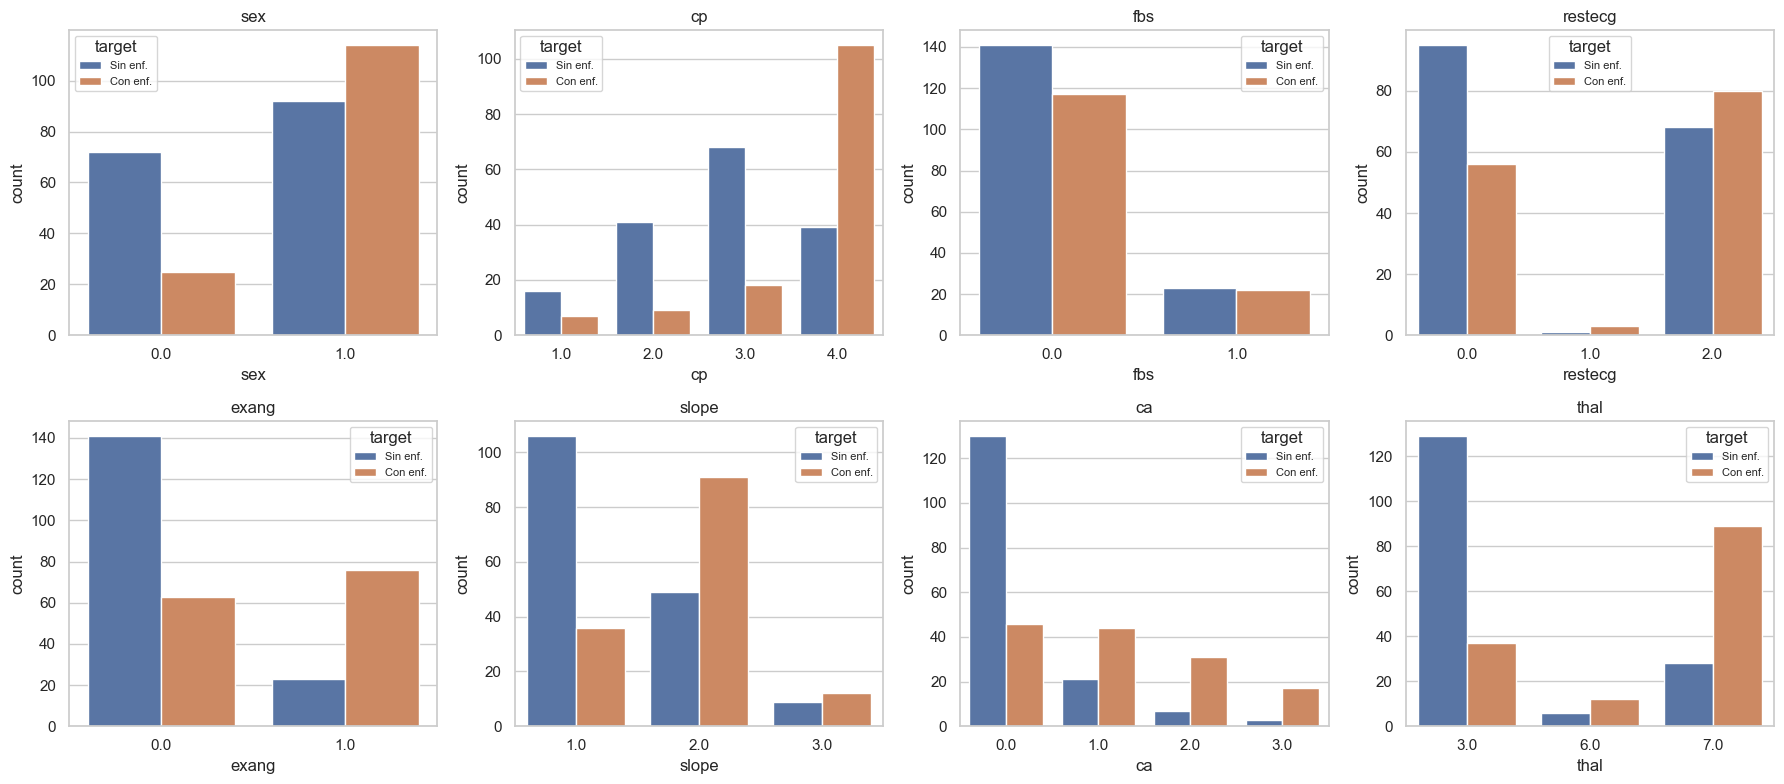

In [10]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()
for i, col in enumerate(categorical_features):
    sns.countplot(data=df, x=col, hue="target", ax=axes[i], palette=PALETTE)
    axes[i].set_title(col)
    axes[i].legend(title="target", labels=["Sin enf.", "Con enf."], fontsize=8)
plt.tight_layout()
plt.show()

In [11]:
for col in ["cp", "thal", "exang"]:
    print(f"\nProporción de enfermedad por categoría de '{col}':")
    print(pd.crosstab(df[col], df["target"], normalize="index").round(3))


Proporción de enfermedad por categoría de 'cp':
target      0      1
cp                  
1.0     0.696  0.304
2.0     0.820  0.180
3.0     0.791  0.209
4.0     0.271  0.729

Proporción de enfermedad por categoría de 'thal':
target      0      1
thal                
3.0     0.777  0.223
6.0     0.333  0.667
7.0     0.239  0.761

Proporción de enfermedad por categoría de 'exang':
target      0      1
exang               
0.0     0.691  0.309
1.0     0.232  0.768


**Lectura de resultados:**

- **`cp`** (tipo de dolor torácico): el tipo **4 (asintomático)** presenta **72.9%** de enfermedad, muy por encima de los tipos 1 (30.4%), 2 (18.0%) y 3 (20.9%). Es un hallazgo aparentemente contraintuitivo pero bien documentado clínicamente: muchos pacientes con enfermedad coronaria significativa cursan *asintomáticos*, mientras que el dolor torácico "típico" suele tener otras causas.
- **`thal`**: defecto fijo (6) y reversible (7) muestran **66.7%** y **76.1%** de enfermedad, frente a solo **22.3%** en thal normal (3) — coincide con la interpretación clínica de la prueba de perfusión con talio.
- **`exang`** (angina inducida por ejercicio): presente → **76.8%** de enfermedad vs. **30.9%** cuando está ausente, consistente con la fisiopatología esperada.

Estas tres variables ya se perfilan como fuertes candidatas discriminantes, lo cual se confirmará más adelante con el análisis de importancia por permutación.

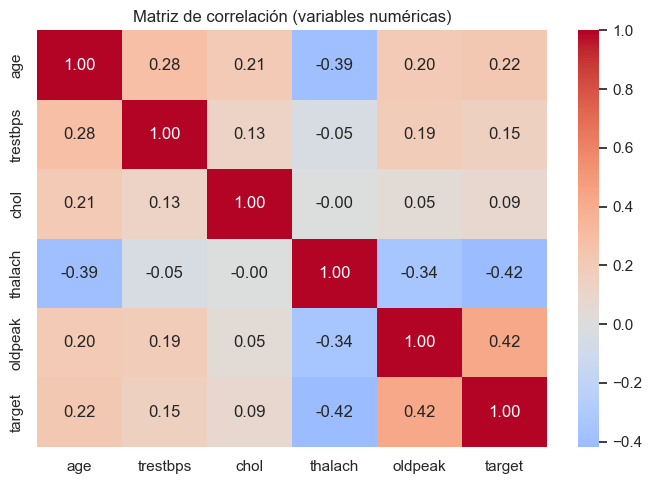

In [12]:
plt.figure(figsize=(7, 5))
corr = df[numeric_features + ["target"]].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Matriz de correlación (variables numéricas)")
plt.tight_layout()
plt.show()

## 6. Preprocesamiento

Se construye un único `ColumnTransformer` —integrado luego en el `Pipeline` de modelado— que aplica:

- **Variables numéricas** (`age`, `trestbps`, `chol`, `thalach`, `oldpeak`): imputación por **mediana** + estandarización (`StandardScaler`). El escalado no es estrictamente necesario para `GaussianNB` (cada variable se modela de forma independiente por clase), pero sí es indispensable para comparar de forma justa con `LogisticRegression` más adelante.
- **Variables categóricas** (`sex`, `cp`, `fbs`, `restecg`, `exang`, `slope`, `ca`, `thal`): imputación por **moda** + codificación **one-hot** (`OneHotEncoder`).

Al encapsular todo en un `Pipeline`, la imputación, el escalado y la codificación se **aprenden únicamente sobre el conjunto de entrenamiento** en cada fold de validación cruzada y se aplican luego al conjunto de prueba, evitando fuga de información (*data leakage*).

In [13]:
X = df.drop(columns=["target"])
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print("Entrenamiento:", X_train.shape, " | Prueba:", X_test.shape)
print(f"Proporción de enfermedad — train: {y_train.mean():.3f}  test: {y_test.mean():.3f}")

Entrenamiento: (242, 13)  | Prueba: (61, 13)
Proporción de enfermedad — train: 0.459  test: 0.459


In [14]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features),
])

## 7. Modelado con `GaussianNB`

Se utiliza `GaussianNB`, que asume que, condicionado a la clase, cada variable numérica sigue una distribución normal, y que las variables son **condicionalmente independientes entre sí dado el diagnóstico** (la asunción "ingenua" de Naive Bayes).

**Nota sobre hiperparámetros:** conforme a la restricción didáctica del proyecto, **no se utiliza `GridSearchCV`**. `GaussianNB` solo expone `var_smoothing`, una constante de estabilidad numérica (evita divisiones por varianza cero) y no un hiperparámetro de control de complejidad del modelo, por lo que no tiene sentido buscarlo exhaustivamente aquí; se deja en su valor por defecto.

In [15]:
gnb_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", GaussianNB()),
])
gnb_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'trestbps', 'chol',
                                                   'thalach', 'oldpeak']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['sex', 'cp', 'fbs',
                                                   'restecg', 'exang', 'slope',
                                                   'ca', 'thal'])])),
                ('classifier', GaussianNB())])

### 7.1 Validación cruzada

In [16]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_accuracy = cross_val_score(gnb_pipeline, X_train, y_train, cv=skf, scoring="accuracy")
cv_auc = cross_val_score(gnb_pipeline, X_train, y_train, cv=skf, scoring="roc_auc")

print("Accuracy por fold:", cv_accuracy.round(3))
print(f"Accuracy CV: {cv_accuracy.mean():.3f} ± {cv_accuracy.std():.3f}")
print(f"AUC CV:      {cv_auc.mean():.3f} ± {cv_auc.std():.3f}")

Accuracy por fold: [0.755 0.735 0.792 0.708 0.729]
Accuracy CV: 0.744 ± 0.028
AUC CV:      0.877 ± 0.021


La validación cruzada estratificada (5 folds, solo sobre el conjunto de entrenamiento) da una **accuracy promedio de 0.744 ± 0.028**: la desviación estándar baja indica que el desempeño del modelo es **estable** entre folds, pese al tamaño reducido del dataset.

## 8. Evaluación en el conjunto de prueba

In [17]:
y_pred = gnb_pipeline.predict(X_test)
y_proba = gnb_pipeline.predict_proba(X_test)[:, 1]

metrics = {
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred),
    "Recall": recall_score(y_test, y_pred),
    "F1-score": f1_score(y_test, y_pred),
    "AUC": roc_auc_score(y_test, y_proba),
}
pd.Series(metrics).round(3)

Accuracy     0.721
Precision    0.641
Recall       0.893
F1-score     0.746
AUC          0.827
dtype: float64

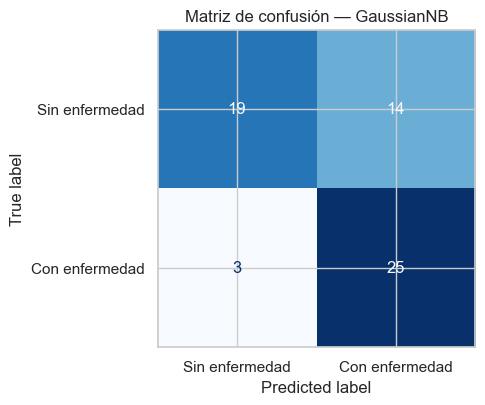

In [18]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Sin enfermedad", "Con enfermedad"])
fig, ax = plt.subplots(figsize=(5, 5))
disp.plot(ax=ax, cmap="Blues", colorbar=False)
plt.title("Matriz de confusión — GaussianNB")
plt.tight_layout()
plt.show()

In [19]:
print(classification_report(y_test, y_pred, target_names=["Sin enfermedad", "Con enfermedad"]))

                precision    recall  f1-score   support

Sin enfermedad       0.86      0.58      0.69        33
Con enfermedad       0.64      0.89      0.75        28

      accuracy                           0.72        61
     macro avg       0.75      0.73      0.72        61
  weighted avg       0.76      0.72      0.72        61



**Lectura clínica de los resultados** (Accuracy=0.721, Precision=0.641, Recall=0.893, F1=0.746, AUC=0.827; matriz de confusión con 19 verdaderos negativos, 14 falsos positivos, 3 falsos negativos y 25 verdaderos positivos):

El modelo tiene un **recall (sensibilidad) muy alto — 89.3%**: de 28 pacientes realmente enfermos, solo **3 no son detectados**. A cambio, la precisión es más baja (64.1%), es decir, genera **14 falsos positivos** que requerirían estudios adicionales para descartar la enfermedad.

En un contexto de **tamizaje (screening) médico**, este balance suele ser deseable: es preferible enviar a algunos pacientes sanos a pruebas adicionales (falso positivo, costo moderado) que dejar de detectar una enfermedad cardíaca real (falso negativo, costo potencialmente grave).

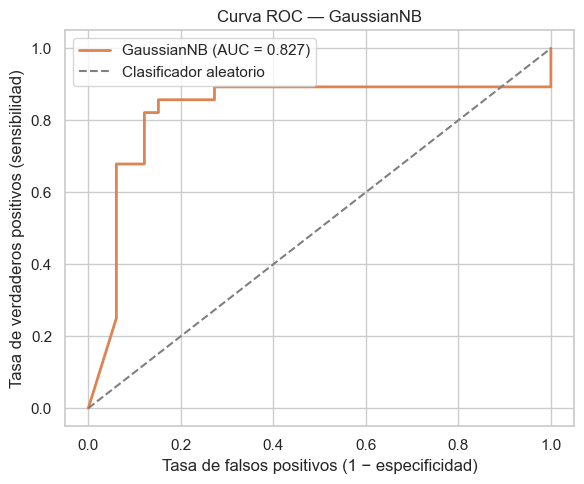

In [20]:
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"GaussianNB (AUC = {roc_auc_score(y_test, y_proba):.3f})",
         color=PALETTE[1], linewidth=2)
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Clasificador aleatorio")
plt.xlabel("Tasa de falsos positivos (1 − especificidad)")
plt.ylabel("Tasa de verdaderos positivos (sensibilidad)")
plt.title("Curva ROC — GaussianNB")
plt.legend()
plt.tight_layout()
plt.show()

### 8.1 Distribución de las probabilidades predichas

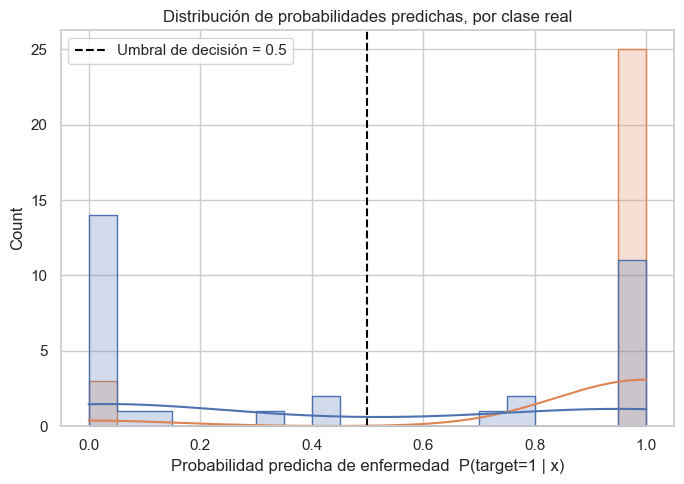

In [21]:
plt.figure(figsize=(7, 5))
etiquetas = y_test.map({0: "Sin enfermedad", 1: "Con enfermedad"})
sns.histplot(x=y_proba, hue=etiquetas, bins=20, kde=True, palette=PALETTE, element="step")
plt.axvline(0.5, color="black", linestyle="--", label="Umbral de decisión = 0.5")
plt.xlabel("Probabilidad predicha de enfermedad  P(target=1 | x)")
plt.title("Distribución de probabilidades predichas, por clase real")
plt.legend()
plt.tight_layout()
plt.show()

Las dos distribuciones están razonablemente separadas (la clase "con enfermedad" se concentra hacia probabilidades altas y viceversa), aunque existe una zona de solapamiento cerca del umbral 0.5 — precisamente ahí se originan los falsos positivos y negativos observados en la matriz de confusión.

### 8.2 Probabilidad condicional aprendida por el modelo

Una de las mayores ventajas interpretativas de `GaussianNB` es que, para cada variable numérica y cada clase, el modelo aprende explícitamente una densidad gaussiana $P(x_j \mid \text{clase})$ mediante su media (`theta_`) y varianza (`var_`). Podemos extraer esos parámetros directamente del pipeline entrenado y visualizarlos.

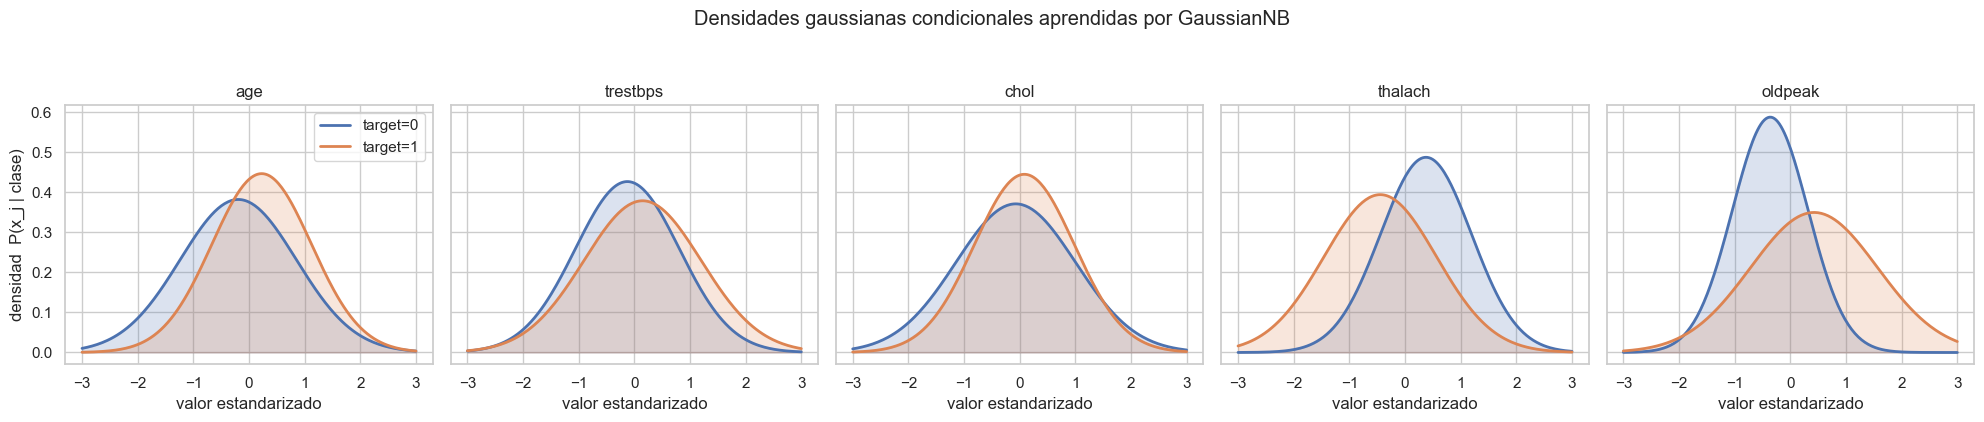

In [22]:
fitted_gnb = gnb_pipeline.named_steps["classifier"]

# Las primeras len(numeric_features) columnas de la matriz transformada
# corresponden, en ese mismo orden, a las variables numéricas ya escaladas.
theta = fitted_gnb.theta_[:, :len(numeric_features)]
var = fitted_gnb.var_[:, :len(numeric_features)]
classes = fitted_gnb.classes_

fig, axes = plt.subplots(1, len(numeric_features), figsize=(20, 4), sharey=True)
x_range = np.linspace(-3, 3, 200)
for j, col in enumerate(numeric_features):
    for c_idx, c in enumerate(classes):
        mu, sigma = theta[c_idx, j], np.sqrt(var[c_idx, j])
        densidad = norm.pdf(x_range, mu, sigma)
        axes[j].plot(x_range, densidad, color=PALETTE[c_idx], linewidth=2,
                     label=f"target={c}")
        axes[j].fill_between(x_range, densidad, alpha=0.2, color=PALETTE[c_idx])
    axes[j].set_title(col)
    axes[j].set_xlabel("valor estandarizado")
axes[0].set_ylabel("densidad  P(x_j | clase)")
axes[0].legend()
plt.suptitle("Densidades gaussianas condicionales aprendidas por GaussianNB", y=1.05)
plt.tight_layout()
plt.show()

Cuanto más separadas estén las dos curvas (azul = sin enfermedad, naranja = con enfermedad) para una variable, mayor es su poder discriminante individual bajo el modelo. Se observa una separación clara en **`thalach`** y **`oldpeak`**, y un solapamiento fuerte en **`chol`** y **`trestbps`** — exactamente lo anticipado en el EDA (sección 5.1).

## 9. Importancia de variables

`GaussianNB` no expone coeficientes ni `feature_importances_`. Para estimar qué variables aportan más a la predicción se usa **importancia por permutación** (*permutation importance*), un método agnóstico al modelo: mide cuánto empeora una métrica (aquí, AUC) al mezclar aleatoriamente los valores de una variable, rompiendo su relación con el objetivo.

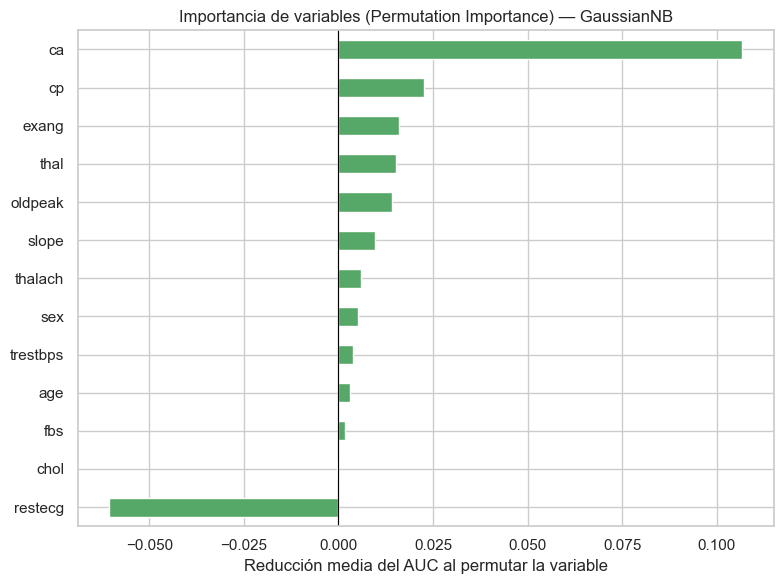

ca          0.106800
cp          0.022583
exang       0.016017
thal        0.015188
oldpeak     0.014177
slope       0.009560
thalach     0.005880
sex         0.005267
trestbps    0.003896
age         0.002994
fbs         0.001659
chol       -0.000289
restecg    -0.060588
dtype: float64

In [23]:
perm_result = permutation_importance(
    gnb_pipeline, X_test, y_test, n_repeats=30, random_state=RANDOM_STATE, scoring="roc_auc"
)
importancia = pd.Series(perm_result.importances_mean, index=X_test.columns).sort_values()

plt.figure(figsize=(8, 6))
importancia.plot(kind="barh", color="#55A868")
plt.xlabel("Reducción media del AUC al permutar la variable")
plt.title("Importancia de variables (Permutation Importance) — GaussianNB")
plt.axvline(0, color="black", linewidth=0.8)
plt.tight_layout()
plt.show()

importancia.sort_values(ascending=False)

Las variables más relevantes son **`ca`** (número de vasos coloreados por fluoroscopia, con una caída de AUC de ≈0.107 — muy por encima de las demás), seguida de **`cp`**, **`exang`** y **`thal`**: las mismas cuatro variables que ya se habían destacado cualitativamente en el EDA. Esto es un buen indicio de coherencia interna del análisis.

`restecg` muestra una importancia **ligeramente negativa**: permutarla no perjudica —e incluso "mejora" levemente— la métrica en este conjunto de prueba. Esto no significa que la variable sea perjudicial, sino que aporta poca o ninguna señal útil, y el pequeño efecto observado es ruido de muestreo propio de un conjunto de prueba de solo 61 pacientes.

## 10. Comparación con otros clasificadores

Como el enunciado sugiere, se compara `GaussianNB` con:

- **`BernoulliNB`**: apropiado cuando las variables están binarizadas/discretizadas (aquí, buena parte de las variables categóricas ya quedan como columnas binarias tras el one-hot encoding).
- **`LogisticRegression`**: modelo discriminativo de referencia que no asume independencia entre variables ni una forma distribucional particular para ellas.

Los tres modelos reutilizan **el mismo `preprocessor`**, cambiando únicamente el clasificador final del pipeline.

In [24]:
models = {
    "GaussianNB": GaussianNB(),
    "BernoulliNB": BernoulliNB(),
    "LogisticRegression": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
}

rows = []
fitted_pipelines = {}
for name, clf in models.items():
    pipe = Pipeline(steps=[("preprocessor", preprocessor), ("classifier", clf)])
    cv_acc = cross_val_score(pipe, X_train, y_train, cv=skf, scoring="accuracy").mean()
    cv_auc = cross_val_score(pipe, X_train, y_train, cv=skf, scoring="roc_auc").mean()
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)
    proba = pipe.predict_proba(X_test)[:, 1]
    fitted_pipelines[name] = pipe
    rows.append({
        "Modelo": name,
        "CV Accuracy": cv_acc,
        "CV AUC": cv_auc,
        "Test Accuracy": accuracy_score(y_test, pred),
        "Test Precision": precision_score(y_test, pred),
        "Test Recall": recall_score(y_test, pred),
        "Test F1": f1_score(y_test, pred),
        "Test AUC": roc_auc_score(y_test, proba),
    })

comparacion = pd.DataFrame(rows).set_index("Modelo").round(3)
comparacion

,CV Accuracy,CV AUC,Test Accuracy,Test Precision,Test Recall,Test F1,Test AUC
Modelo,,,,,,,
GaussianNB,0.744,0.877,0.721,0.641,0.893,0.746,0.827
BernoulliNB,0.818,0.904,0.902,0.844,0.964,0.900,0.964
LogisticRegression,0.847,0.902,0.885,0.839,0.929,0.881,0.966


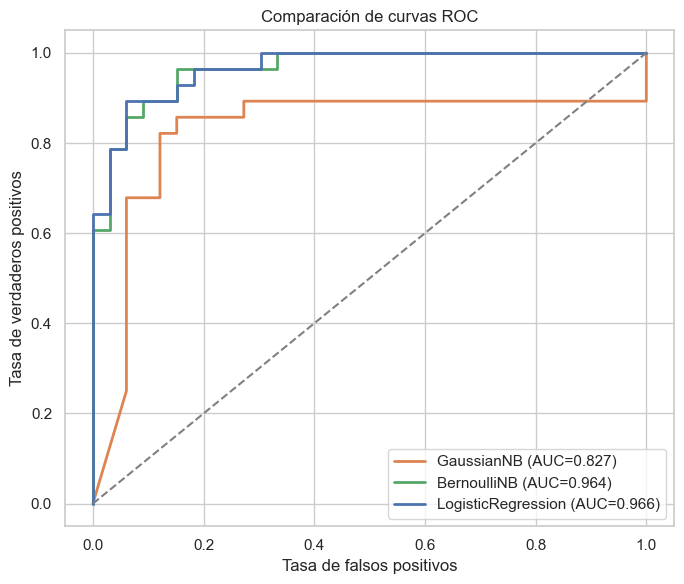

In [25]:
plt.figure(figsize=(7, 6))
colors = {"GaussianNB": "#DD8452", "BernoulliNB": "#55A868", "LogisticRegression": "#4C72B0"}
for name, pipe in fitted_pipelines.items():
    proba = pipe.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC={roc_auc_score(y_test, proba):.3f})",
             color=colors[name], linewidth=2)
plt.plot([0, 1], [0, 1], "--", color="gray")
plt.xlabel("Tasa de falsos positivos")
plt.ylabel("Tasa de verdaderos positivos")
plt.title("Comparación de curvas ROC")
plt.legend()
plt.tight_layout()
plt.show()

**Lectura de la comparación** (valores reales de la tabla anterior):

| Modelo | CV Accuracy | CV AUC | Test Accuracy | Test AUC |
|---|---|---|---|---|
| GaussianNB | 0.744 | 0.877 | 0.721 | 0.827 |
| BernoulliNB | 0.818 | 0.904 | 0.902 | 0.964 |
| LogisticRegression | 0.847 | 0.902 | 0.885 | 0.966 |

En **validación cruzada** (la comparación más confiable, al promediar 5 folds), `LogisticRegression` obtiene el mejor resultado, seguido muy de cerca por `BernoulliNB`; `GaussianNB` queda por debajo en ambas métricas. Una explicación razonable: `GaussianNB` asume que **todas** las variables —incluidas las categóricas codificadas en one-hot— siguen una distribución gaussiana, y que son condicionalmente independientes entre sí dado el diagnóstico. Ambos supuestos son poco realistas aquí (por ejemplo, `thal` y `cp` están clínicamente relacionadas), lo que penaliza su desempeño frente a modelos que no dependen de ellos.

Aun así, la brecha de AUC en validación cruzada no es enorme (0.877 frente a 0.902-0.904), lo que confirma que el clasificador bayesiano ingenuo sigue siendo una alternativa razonable, en particular quirúrgica por su simplicidad, velocidad y total interpretabilidad probabilística.

## 11. Discusión: fortalezas y limitaciones del modelo bayesiano

**Fortalezas de `GaussianNB` en este problema:**

- Extremadamente rápido de entrenar y predecir — relevante en sistemas clínicos con recursos computacionales limitados.
- Totalmente interpretable: cada predicción puede desglosarse como el producto de probabilidades condicionales por variable (sección 8.2).
- Funciona razonablemente bien con pocos datos (303 registros) y sin necesidad de ajustar hiperparámetros de complejidad.
- Entrega probabilidades explícitas y calibrables, útiles para comunicar el riesgo estimado al personal médico, no solo una etiqueta binaria.

**Limitaciones evidenciadas:**

- **Asunción de independencia condicional** entre variables dado el diagnóstico, que sabemos falsa: `cp`/`thal`, o `exang`/`oldpeak`, están clínicamente relacionadas entre sí.
- **Asunción de normalidad**: se aplica también, por construcción del pipeline, a variables categóricas codificadas como 0/1 — una aproximación pobre, como lo evidencia la mejora de `BernoulliNB` (que sí modela variables binarias correctamente) sobre las mismas columnas.
- Desempeño inferior, tanto en accuracy como en AUC, frente a `LogisticRegression` y `BernoulliNB` en este dataset.
- No incorpora selección de variables ni penalización por variables ruidosas o irrelevantes.

## 12. Reflexión sobre interpretabilidad y aplicabilidad médica

En un escenario de **tamizaje clínico**, la sensibilidad (recall) suele ser la métrica prioritaria: es preferible generar algunos falsos positivos —pacientes sanos enviados a estudios adicionales— que dejar pasar un falso negativo —un paciente enfermo no detectado—. El recall de 89.3% obtenido por `GaussianNB` es clínicamente favorable bajo ese criterio, incluso con una precisión moderada (64.1%).

La salida probabilística explícita de `GaussianNB`, junto con la posibilidad de graficar directamente las densidades condicionales aprendidas por variable (sección 8.2), lo convierten en una herramienta valiosa para **explicar** el rol de cada indicador clínico a un equipo médico, más allá de su desempeño puro.

Dado que su capacidad discriminativa (AUC) es inferior a la de `BernoulliNB` o `LogisticRegression`, en un despliegue real convendría usar `GaussianNB` principalmente como **modelo base interpretable** para comunicar el peso relativo de cada variable, y reservar el modelo de mayor AUC para la decisión final — siempre acompañado de validación clínica externa, dado que el dataset (303 pacientes de un único centro, Cleveland Clinic) es pequeño y no necesariamente representativo de otras poblaciones.

## 13. Conclusiones

1. Se construyó un pipeline reproducible (imputación → codificación → escalado → `GaussianNB`) que cumple con las restricciones didácticas del proyecto: uso obligatorio de `Pipeline`, sin `GridSearchCV`.
2. `GaussianNB` alcanzó **Accuracy = 0.721, Recall = 0.893, F1 = 0.746 y AUC = 0.827** en el conjunto de prueba, con una validación cruzada estable (Accuracy = 0.744 ± 0.028).
3. Las variables más relevantes según importancia por permutación fueron **`ca`, `cp`, `exang` y `thal`**, coherentes con el conocimiento clínico del dominio y con los patrones observados en el EDA.
4. El desempeño de `GaussianNB` fue consistentemente inferior al de `BernoulliNB` y `LogisticRegression`, evidenciando el costo de sus asunciones simplificadoras (independencia condicional y normalidad de todas las variables); aun así, sigue siendo un modelo valioso por su velocidad, simplicidad e interpretabilidad probabilística.
5. En el contexto médico de este proyecto, el modelo bayesiano resulta más útil como **herramienta de apoyo diagnóstico interpretable y de bajo costo computacional** que como clasificador final de máxima precisión.

## 14. Referencias

- Detrano, R., et al. (1989). *International application of a new probability algorithm for the diagnosis of coronary artery disease.* American Journal of Cardiology.
- Dua, D. and Graff, C. (2019). *UCI Machine Learning Repository — Heart Disease Data Set.* University of California, Irvine. https://archive.ics.uci.edu/ml/datasets/Heart+Disease
- Documentación de scikit-learn: `GaussianNB`, `BernoulliNB`, `Pipeline`, `ColumnTransformer`, `permutation_importance`. https://scikit-learn.org/stable/